<h1 style="color:#117A65;">🛒 E-Commerce Customer Churn & RFM Segmentation Analysis</h1>

<h2 style='color:#117A65;'>1. Project Objective</h2>

Customer churn poses a major challenge for e-commerce and subscription-based platforms, as retaining existing customers is significantly more 
cost effective than acquiring new ones. This project conducts an end-to-end analysis on a comprehensive Customer Engagement and Churn Analytics dataset of 50,000 customers across multiple countries, utilizing behavioral, demographic, and transactional data along with RFM (Recency, Frequency, Monetary) segmentation to assess customer value, identify churn risk, and derive actionable retention strategies.

<h2 style='color:#117A65;'>2. Problem Statement</h2>
    E-commerce companies often struggle with:
    
- Declining customer retention

- Inefficient marketing spend

- Lack of personalized engagement strategies

- Poor understanding of customer value and behavior

- Despite having access to large amounts of customer data, many organizations rely on generic marketing approaches, treating all customers the same.

- This results in missed revenue opportunities, increased churn, and reduced customer lifetime value.

<h2 style='color:#117A65;'>3. Dataset Overview</h2>

#### Import the Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

### **Column Descriptions**
- ##### **Age**: Customer's age in years (numerical)
- ##### **Gender**: Customer's gender (Male/Female)
- ##### **Country**: Country of customer residence (USA, UK, Canada, Germany, India, Japan, France, Australia)
- ##### **City**: City where the customer is located
- ##### **Membership_Year**s: Number of years the customer has been a member of the platform
- ##### **Login_Frequency**: Average number of logins per month
- ##### **Session_Duration_Avg**: Average session duration in minutes
- ##### **Pages_Per_Session**: Average pages viewed per session
- ##### **Cart_Abandonment_Rate**: Percentage of abandoned shopping carts
- ##### **Wishlist_Items**: Number of items in customer's wishlist
- ##### **Total_Purchases**: Total number of purchases made
- ##### **Average_Order_Value**: Average value per order in currency units
- ##### **Days_Since_Last_Purchase**: Number of days since most recent purchase
- ##### **Discount_Usage_Rate**: Percentage of purchases using discounts
- ##### **Returns_Rate**: Percentage of items returned
- ##### **Email_Open_Rate**: Percentage of marketing emails opened
- ##### **Customer_Service_Calls**: Number of items in customer's wishlist
- ##### **Product_Reviews_Written**: Number of product reviews submitted
- ##### **Social_Media_Engagement_Score**: Social media interaction score (0-100)
- ##### **Mobile_App_Usage**: Percentage of activity via mobile app
- ##### **Payment_Method_Diversity**: Number of different payment methods used
- ##### **Lifetime_Value**: Total customer lifetime value in currency units
- ##### **Credit_Balance**: Current account credit balance
- ##### **Churned**: Target variable - whether customer has churned (0=Active, 1=Churned)
- ##### **Signup_Quarter**: Quarter when customer signed up (Q1-Q4) 

#### Load the Dataset

In [39]:
df = pd.read_csv(r"C:\Users\fathi\OneDrive\Documents\excel data analytics\project dataset.csv")

In [40]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38.0,Female,USA,Los Angeles,10.0,10,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2


### Shape of the Dataset

In [41]:
print("Dataset Rows: ",df.shape[0])
print("Dataset Columns: ",df.shape[1])

Dataset Rows:  50000
Dataset Columns:  25


### First five rows of the Datatset

In [42]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


### Last five rows of the Dataset

In [43]:
df.tail()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
49995,38.0,Female,USA,Los Angeles,10.0,10,35.8,8.8,51.2,3.0,...,9.2,5.0,1.0,20.7,25.2,1.0,2365.98,3499.0,0,Q2
49996,37.0,Male,USA,Chicago,1.4,21,32.4,9.6,32.5,2.0,...,17.6,5.0,3.0,38.6,12.1,4.0,1293.60,3154.0,0,Q3
49997,44.0,Female,USA,Phoenix,2.8,19,40.3,10.4,50.6,1.0,...,25.2,4.0,6.0,59.9,NaN,1.0,1655.28,1622.0,0,Q1
49998,41.0,Female,USA,Chicago,2.9,17,29.9,10.1,60.8,1.0,...,34.6,5.0,2.0,NaN,14.1,3.0,1286.11,2634.0,0,Q2
49999,56.0,Male,UK,Leeds,2.2,2,18.2,NaN,46.0,0.0,...,0.0,7.0,0.0,0.0,4.2,1.0,1072.61,612.0,0,Q3


### Datatypes of each column

In [44]:
df.dtypes

Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                    int64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

<h2 style='color:#117A65;'>4. Data Cleaning</h2>

### Information about the Datataset

In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  int64  
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

### Sum of the missing values

In [46]:
df.isnull().sum().sort_values(ascending=False)

Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Discount_Usage_Rate              3500
Product_Reviews_Written          3500
Session_Duration_Avg             3399
Days_Since_Last_Purchase         3000
Pages_Per_Session                3000
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Age                              2495
Customer_Service_Calls            168
Gender                              0
Average_Order_Value                 0
Total_Purchases                     0
Cart_Abandonment_Rate               0
Login_Frequency                     0
Membership_Years                    0
City                                0
Lifetime_Value                      0
Country                             0
Churned                             0
Signup_Quarter                      0
dtype: int64

### Drop the missing values in Age column 

In [47]:
df = df.dropna(subset=['Age'])

### Handling missing values using median

In [48]:
df=df.copy()

In [49]:
# Handling missing values values in Session_Duration_Avg
df['Session_Duration_Avg'] = df['Session_Duration_Avg'].fillna(df['Session_Duration_Avg'].median())

In [50]:
# Handling missing values in Pages_Per_Session column
df['Pages_Per_Session'] = df['Pages_Per_Session'].fillna(df['Pages_Per_Session'].median())

In [51]:
# Handling missing values in Wishlist_items column
df['Wishlist_Items'] = df['Wishlist_Items'].fillna(df['Wishlist_Items'].median())

In [52]:
# Handling missing values in Days_Since_Last_Purchase column
df['Days_Since_Last_Purchase'] = df['Days_Since_Last_Purchase'].fillna(df['Days_Since_Last_Purchase'].median())

In [53]:
# Handling missing values in Discount_Usage_Rate column
df['Discount_Usage_Rate'] = df['Discount_Usage_Rate'].fillna(df['Discount_Usage_Rate'].median())

In [54]:
# Handling missing values in Returns_Rate column
df['Returns_Rate'] = df['Returns_Rate'].fillna(df['Returns_Rate'].median())

In [55]:
# Handling missing values in Email_open_Rate column
df['Email_Open_Rate'] = df['Email_Open_Rate'].fillna(df['Email_Open_Rate'].median())

In [56]:
# Handling missing values in Discount_Usage_Rate column
df['Customer_Service_Calls'] = df['Customer_Service_Calls'].fillna(df['Customer_Service_Calls'].median())

In [57]:
# Handling missing values in Product_Reviews_Written
df['Product_Reviews_Written'] = df['Product_Reviews_Written'].fillna(df['Product_Reviews_Written'].median())

In [58]:
# Handling missing values in Social_Media_Engagement_Score
df['Social_Media_Engagement_Score'] = df['Social_Media_Engagement_Score'].fillna(df['Social_Media_Engagement_Score'].median())

In [59]:
# Handling missing values in Mobile_App_Usage
df['Mobile_App_Usage'] = df['Mobile_App_Usage'].fillna(df['Mobile_App_Usage'].median())

In [60]:
# Handling missing values in Payment_Method_Diversity
df['Payment_Method_Diversity'] = df['Payment_Method_Diversity'].fillna(df['Payment_Method_Diversity'].median())

In [61]:
# Handling missing values in Credit_Balance
df['Credit_Balance'] = df['Credit_Balance'].fillna(df['Credit_Balance'].median())

#### Deletd the signup quarter column because it only shows how customers are divided based on their signup period, and it does not have any significant impact on our analysis.


In [62]:
df.drop('Signup_Quarter', axis=1, inplace=True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47505 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         47505 non-null  object 
 2   Country                        47505 non-null  object 
 3   City                           47505 non-null  object 
 4   Membership_Years               47505 non-null  float64
 5   Login_Frequency                47505 non-null  int64  
 6   Session_Duration_Avg           47505 non-null  float64
 7   Pages_Per_Session              47505 non-null  float64
 8   Cart_Abandonment_Rate          47505 non-null  float64
 9   Wishlist_Items                 47505 non-null  float64
 10  Total_Purchases                47505 non-null  float64
 11  Average_Order_Value            47505 non-null  float64
 12  Days_Since_Last_Purchase       47505 non-null  floa

### Converting datatype into integer

In [64]:
count_cols = [
    'Age', 'Membership_Years', 'Pages_Per_Session',
    'Wishlist_Items', 'Total_Purchases',
    'Customer_Service_Calls', 'Product_Reviews_Written',
    'Days_Since_Last_Purchase', 'Mobile_App_Usage',
    'Payment_Method_Diversity'
]

df[count_cols] = df[count_cols].round().astype(int)

### Converting the datatypes into time

In [65]:
df['Session_Duration_Avg'] = pd.to_timedelta(
    df['Session_Duration_Avg'], unit='m'
)

### Descriptive Statistics of the columns

In [66]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,47505.000000,47505.000000,47505,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,...,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000,47505.000000
mean,37.802968,2.979160,11.625808,0 days 00:27:37.188253868,8.698726,57.065184,4.274161,13.112809,123.304715,29.285759,...,6.562013,20.894285,5.680181,2.794990,29.173171,19.347900,2.338722,1440.892865,1959.203137,0.290896
std,11.834668,2.087042,7.820337,0 days 00:10:30.303128499,3.676297,16.283426,3.061014,7.027137,179.827664,28.869159,...,5.857375,13.894513,2.670555,2.255118,19.312793,8.952874,1.085948,906.986067,1155.914290,0.454180
min,5.000000,0.000000,0.000000,0 days 00:01:00,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.000000,6.000000,0 days 00:20:18,6.000000,46.500000,2.000000,8.000000,87.040000,9.000000,...,3.100000,10.500000,4.000000,1.000000,15.400000,13.000000,2.000000,789.580000,1166.000000,0.000000
50%,38.000000,2.000000,11.000000,0 days 00:26:48,8.000000,58.100000,4.000000,12.000000,112.960000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,19.000000,2.000000,1243.800000,1897.000000,0.000000
75%,46.000000,4.000000,17.000000,0 days 00:34:06,11.000000,68.700000,6.000000,17.000000,144.480000,39.000000,...,8.600000,29.700000,7.000000,4.000000,40.700000,25.000000,3.000000,1874.870000,2663.000000,1.000000
max,200.000000,10.000000,46.000000,0 days 01:15:36,24.000000,143.743350,28.000000,129.000000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,62.000000,5.000000,8987.240000,7197.000000,1.000000


#### Check for duplicates values

In [67]:
# Check for duplicate columns --> there is no any duplicates
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [68]:
df.dtypes

Age                                        int64
Gender                                    object
Country                                   object
City                                      object
Membership_Years                           int64
Login_Frequency                            int64
Session_Duration_Avg             timedelta64[ns]
Pages_Per_Session                          int64
Cart_Abandonment_Rate                    float64
Wishlist_Items                             int64
Total_Purchases                            int64
Average_Order_Value                      float64
Days_Since_Last_Purchase                   int64
Discount_Usage_Rate                      float64
Returns_Rate                             float64
Email_Open_Rate                          float64
Customer_Service_Calls                     int64
Product_Reviews_Written                    int64
Social_Media_Engagement_Score            float64
Mobile_App_Usage                           int64
Payment_Method_Diver

#### Create column called Customer ID for RFM Segmentation

In [69]:
df['Customer_ID'] = range(1,len(df)+1)

In [70]:
df

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Customer_ID
0,43,Male,France,Marseille,3,14,0 days 00:27:24,6,50.6,3,...,17.9,9,4,16.3,21,1,953.33,2278.0,0,1
1,36,Male,UK,Manchester,2,15,0 days 00:42:42,10,37.7,1,...,42.8,7,3,27.6,23,3,1067.47,3028.0,0,2
2,45,Female,Canada,Vancouver,3,10,0 days 00:24:48,2,70.9,1,...,0.0,4,1,27.6,9,2,1289.75,2317.0,0,3
3,56,Female,USA,New York,3,10,0 days 00:38:24,15,41.7,9,...,41.4,2,5,85.9,31,3,2340.92,2674.0,0,4
4,35,Male,India,Delhi,3,29,0 days 00:51:24,8,19.1,9,...,37.9,1,11,83.0,50,4,3041.29,5354.0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,38,Female,USA,Los Angeles,10,10,0 days 00:35:48,9,51.2,3,...,9.2,5,1,20.7,25,1,2365.98,3499.0,0,47501
49996,37,Male,USA,Chicago,1,21,0 days 00:32:24,10,32.5,2,...,17.6,5,3,38.6,12,4,1293.60,3154.0,0,47502
49997,44,Female,USA,Phoenix,3,19,0 days 00:40:18,10,50.6,1,...,25.2,4,6,59.9,19,1,1655.28,1622.0,0,47503
49998,41,Female,USA,Chicago,3,17,0 days 00:29:54,10,60.8,1,...,34.6,5,2,27.6,14,3,1286.11,2634.0,0,47504


#### Check for null values

In [71]:
df.isnull().sum().sort_values(ascending=False)

Age                              0
Discount_Usage_Rate              0
Churned                          0
Credit_Balance                   0
Lifetime_Value                   0
Payment_Method_Diversity         0
Mobile_App_Usage                 0
Social_Media_Engagement_Score    0
Product_Reviews_Written          0
Customer_Service_Calls           0
Email_Open_Rate                  0
Returns_Rate                     0
Days_Since_Last_Purchase         0
Gender                           0
Average_Order_Value              0
Total_Purchases                  0
Wishlist_Items                   0
Cart_Abandonment_Rate            0
Pages_Per_Session                0
Session_Duration_Avg             0
Login_Frequency                  0
Membership_Years                 0
City                             0
Country                          0
Customer_ID                      0
dtype: int64

<h2 style='color:#117A65;'>5. Exploratory Data Analysis</h2>

### **RFM Segmentation**

#### RFM stands for Recency, Frequency, Monetary Value and it is the technique of customer segmentation based on their transaction history.
The RFM analysis is based on three criterias, which measure different customer characteristics:
- Recency: Days since last purchase/order of the client.
- Frequency: Total number of purchases the customer were made.
- Monetary Value: Total money the customer spent per order.
  
Customer segmentation can be performed using the classic RFM method, assigning them ratings from 1 to 4.
Four is the best / highest value and one is the lowest / worst value.
The final RFM score is calculated by combining the individual score numbers into one column to create RFM value classes for our customers.

For making RFM analysis need only four columns: Customer_ID, Days_Since_Last_Purchase, Total_Purchases, Average_Order_Value

##### Create column called Customer ID for RFM Analysis

In [72]:
rfm = df[['Customer_ID',
          'Days_Since_Last_Purchase',
          'Total_Purchases',
          'Average_Order_Value']]

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

In [73]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [74]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(int) +
    rfm['F_score'].astype(int) +
    rfm['M_score'].astype(int)
)

In [75]:
def segment(row):
    
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    
    elif row['R_score'] >= 4 and row['F_score'] >= 3:
        return 'Loyal Customers'
    
    elif row['F_score'] >= 4:
        return 'Frequent Buyers'
    
    elif row['R_score'] <= 2:
        return 'At Risk'
    
    else:
        return 'Others'


rfm['Segment'] = rfm.apply(segment, axis=1)

In [76]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,1,34,9,94.72,2,2,2,6,At Risk
1,2,71,20,82.45,1,5,2,8,Frequent Buyers
2,3,11,9,165.52,4,2,5,11,Others
3,4,47,15,147.33,1,4,4,9,Frequent Buyers
4,5,73,32,141.30,1,5,4,10,Frequent Buyers


In [77]:
rfm['Segment'].value_counts()

Segment
Others             13166
At Risk            11384
Frequent Buyers    11055
Loyal Customers     8726
Champions           3174
Name: count, dtype: int64

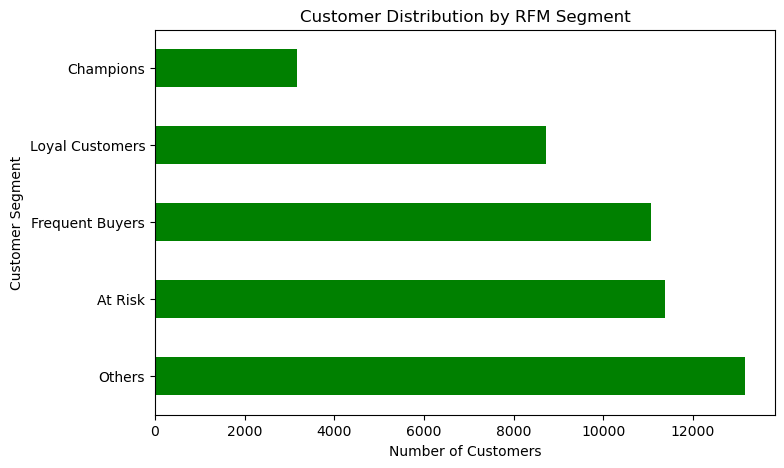

In [78]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))

segment_counts.plot(kind='barh', color='green')

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

plt.show()

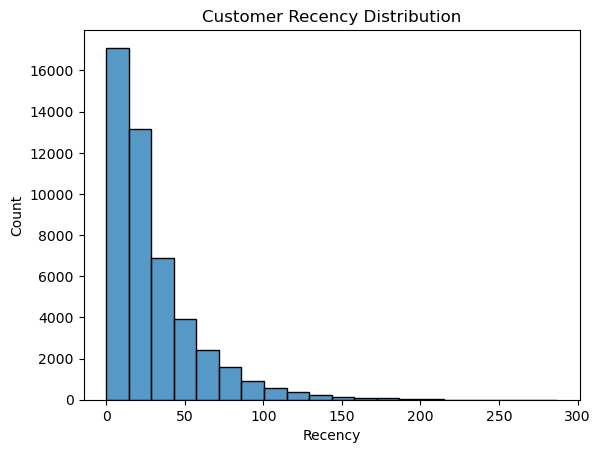

In [79]:
sns.histplot(rfm['Recency'], bins=20)
plt.title("Customer Recency Distribution")
plt.show()

#### **Insight**
- Champions and Loyal Customers are the most valuable segment as they purchase frequently, spend more, and actively engage with the platform. They contribute significantly to revenue and should be retained through loyalty programs and personalized offers.

- Frequent Buyers show consistent purchasing behavior and represent a strong growth segment that can potentially become champions with targeted engagement strategies.

- At Risk customers were previously active but have recently reduced their engagement, making them more likely to churn. Re-engagement campaigns such as discounts or reminders can help retain them.

- Other or low-value segments have lower purchasing frequency and engagement, resulting in a smaller contribution to overall revenue.

### **1.Univariate Analysis**

#### 1.1 Customers count in a country

#### **Objective** 
To analyze the geographical distribution of customers in the dataset and identify which countries contribute the largest share of users on the platform.

In [80]:
df.groupby('Country').size().sort_values(ascending=False)

Country
USA          16505
UK            7184
Canada        5719
Germany       4671
Australia     3862
France        3793
India         3330
Japan         2441
dtype: int64

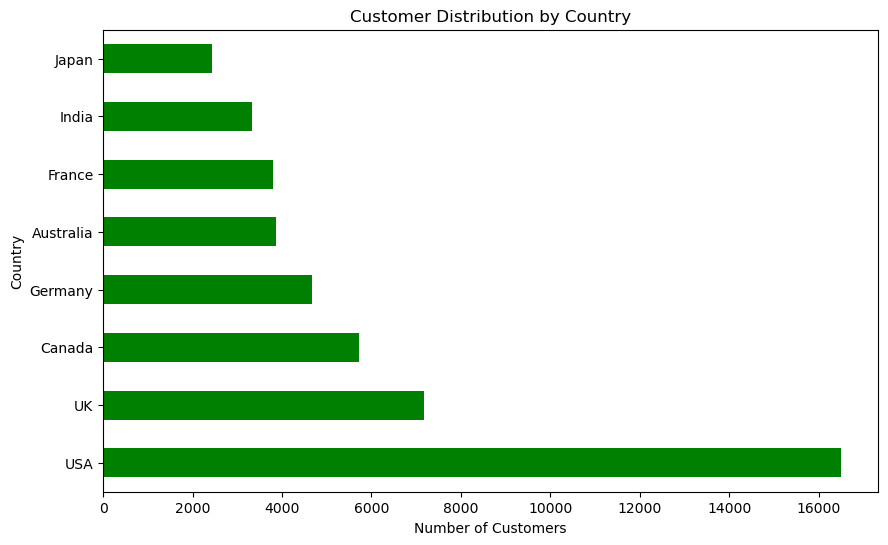

In [81]:
Country = df['Country'].value_counts()

plt.figure(figsize=(10,6))
Country.plot(kind='barh', color='green')

plt.title('Customer Distribution by Country')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.show()

#### **Insight**
- The dataset shows that the USA has the highest number of customers (16,505), indicating that the platform has its strongest presence in the United States.
- The UK (7,184) and Canada (5,719) also contribute a significant portion of the customer based.

#### **1.2 Gender Distribution**

#### **Objective**

To examine the distribution of customers across different gender categories in the dataset and understand the composition of the customer base.

In [82]:
df['Gender'].value_counts()

Gender
Female    23873
Male      22752
Other       880
Name: count, dtype: int64

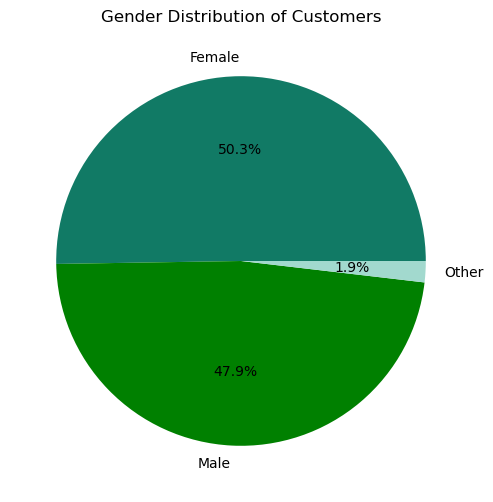

In [83]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#117A65','Green','#A2D9CE']
)

plt.title('Gender Distribution of Customers')
plt.ylabel('')

plt.show()

#### **Insight**
The output shows the number of customers belonging to each gender category

#### **1.3 Age Distribution among the Customers**

#### **Objective** 
To understand the distribution of customers across different age groups.

In [84]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0,18,30,45,60,100],
                         labels=['Teen','Young Adult','Adult','Middle Age','Senior'])

In [85]:
df['Age_Group'].value_counts()

Age_Group
Adult          22109
Middle Age     10728
Young Adult    10669
Teen            2669
Senior          1310
Name: count, dtype: int64

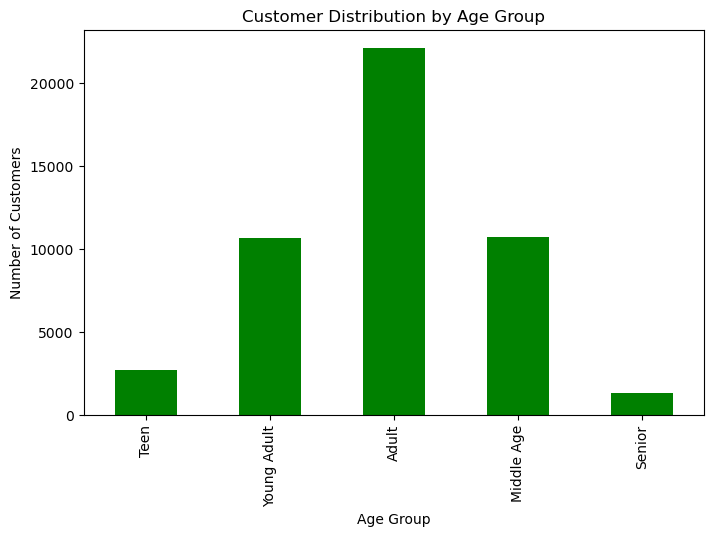

In [86]:
age_counts = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(8,5))
age_counts.plot(kind='bar', color='Green')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

#### **Insight**
This shows adult has the highest number of customers. It helps identify the primary target audience of the platform.

#### **1.4 Customer Churn Distribution**

#### **Objective**
To analyze the distribution of customers based on their churn status, helping understand how many customers have left the platform versus those who remain active.

In [87]:
df['Churned'].value_counts()

Churned
0    33686
1    13819
Name: count, dtype: int64

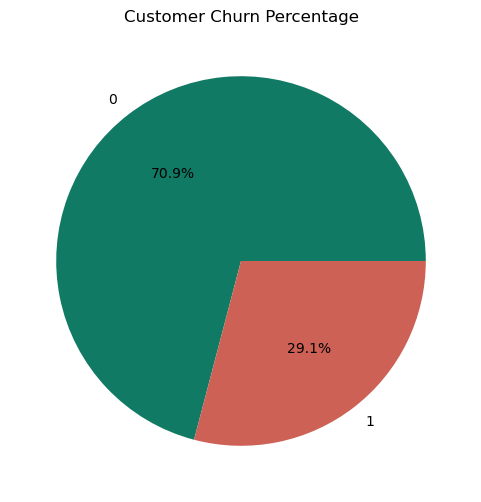

In [88]:
plt.figure(figsize=(6,6))

df['Churned'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#117A65','#CD6155']
)

plt.title('Customer Churn Percentage')
plt.ylabel('')

plt.show()

#### **Insight**
The output shows the number of churned and non-churned customers in the dataset.

#### **1.5 Pages Per Session**

#### **Objective**
To analyze the number of pages customers view during a single session, helping understand their browsing behavior and engagement level on the platform.

In [89]:
df['Pages_Per_Session'].agg(['count','mean','median','min','max','std']).round(0).astype(int)

count     47505
mean          9
median        8
min           1
max          24
std           4
Name: Pages_Per_Session, dtype: int64

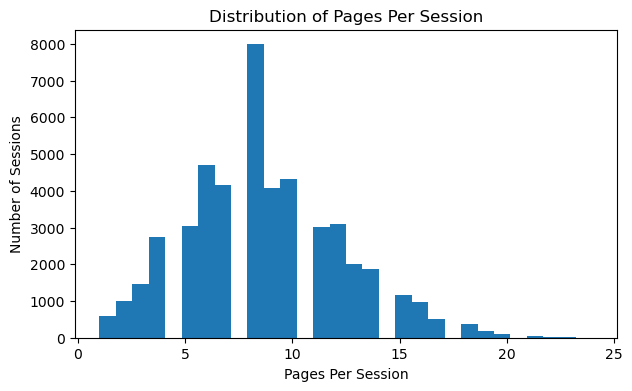

In [90]:
plt.figure(figsize=(7,4))

plt.hist(df['Pages_Per_Session'], bins=30)

plt.title('Distribution of Pages Per Session')
plt.xlabel('Pages Per Session')
plt.ylabel('Number of Sessions')

plt.show()

#### **Insight**
- The results show that customers view an average of about 8 pages per session, with a median of 8 pages.
- Indicating that most users browse around 8 pages during each visit.
- The standard deviation of 3.68 suggests moderate variation in browsing behavior among customers.
- The minimum value of 1 page indicates that some users visit only a single page before leaving.
- While the maximum value of 24 pages shows that highly engaged users explore many pages during their session.

### **2.Bivariate Analysis**

#### **2.1 Churned VS Membership Years**

#### **Objective** : 
To determine whether customer tenure affects churn behavior.

In [91]:
df.groupby('Churned')['Membership_Years'].mean()

Churned
0    2.980229
1    2.976554
Name: Membership_Years, dtype: float64

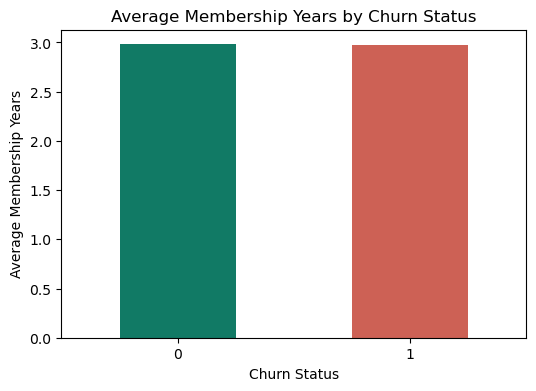

In [92]:
membership_mean = df.groupby('Churned')['Membership_Years'].mean()
plt.figure(figsize=(6,4))
membership_mean.plot(kind='bar', color=['#117A65','#CD6155'])
plt.title('Average Membership Years by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average Membership Years')
plt.xticks(rotation=0)
plt.show()

#### **Insight :**
- The average membership duration for both churned and non-churned customers is almost identical (around 3 years). 
- This indicates that membership tenure alone does not significantly influence customer churn in this dataset.

#### **2.2 Average orders VS Churned and Non-Churned**

#### **Objective** : 
To analyze average number of orders differ between churned and non-churned customers.

In [93]:
pd.pivot_table(df,
               values='Average_Order_Value',
               index='Churned',
               aggfunc='mean')

,Average_Order_Value
Churned,
0,118.586601
1,134.805864


<Figure size 600x400 with 0 Axes>

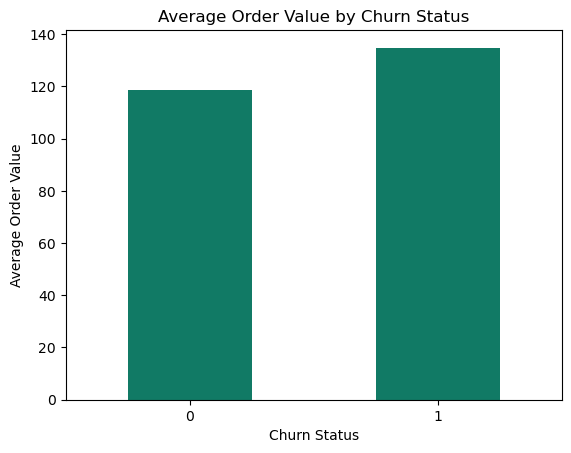

In [94]:
plt.figure(figsize=(6,4))
pd.pivot_table(df,
               values='Average_Order_Value',
               index='Churned',
               aggfunc='mean').plot(kind='bar',
                                    color=['#117A65','#CD6155'],
                                    legend=False)
plt.title('Average Order Value by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average Order Value')
plt.xticks(rotation=0)
plt.show()

### **Insight**
- High spending does not guarantee customer retention
- Some customers may make few but high-value purchases and then stop buying
- These customers might not be frequent or consistently engaged

#### **2.3 Total Purchases VS Gender**

#### **Objective**: 
To compare the average number of purchases made by different gender groups.

In [95]:
pd.pivot_table(df,
               values='Total_Purchases',
               index='Gender',
               aggfunc='mean')

,Total_Purchases
Gender,
Female,13.098396
Male,13.116341
Other,13.412500


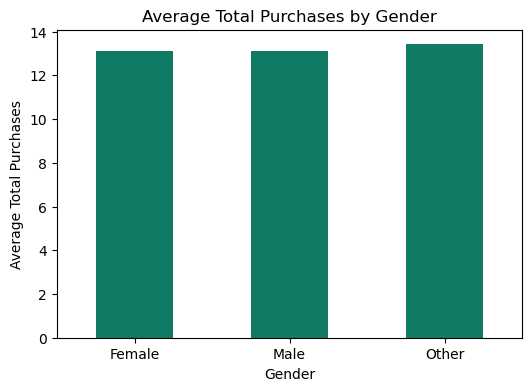

In [96]:
pd.pivot_table(df,
               values='Total_Purchases',
               index='Gender',
               aggfunc='mean').plot(kind='bar',
                                    figsize=(6,4),
                                    color='#117A65',
                                    legend=False)
plt.title('Average Total Purchases by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Total Purchases')

plt.xticks(rotation=0)

plt.show()

#### **Insight** 
- The results show that the average number of purchases is very similar across all gender groups.
- Male customers have an average of 13.11 purchases.
- Female customers have 13.09 purchases.
- Customers categorized as Other have slightly higher purchases at 13.41.
- The differences are minimal, indicating that purchasing behavior is fairly consistent across genders.

#### **2.4 Impact of Login Activity on Customer Churn**

#### **Objective** : 
To analyze whether login activity influences customer churn.

In [97]:
df.groupby('Churned')[['Login_Frequency']].mean()

,Login_Frequency
Churned,
0,12.644095
1,9.143570


<Figure size 600x400 with 0 Axes>

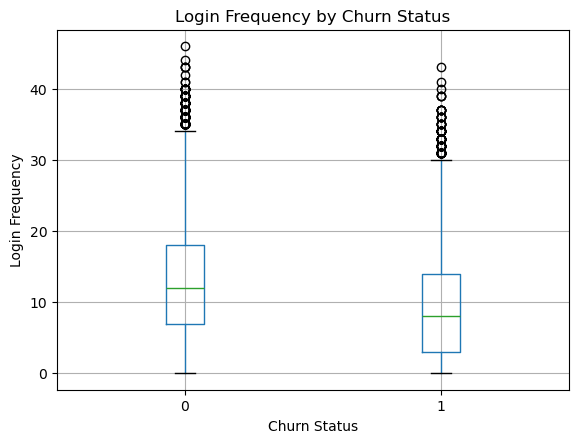

In [98]:
plt.figure(figsize=(6,4))

df.boxplot(column='Login_Frequency', by='Churned')

plt.title('Login Frequency by Churn Status')
plt.suptitle('')
plt.xlabel('Churn Status')
plt.ylabel('Login Frequency')
plt.show()

#### **Insight** 
- The box plot indicates that non-churned customers have a significantly higher login frequency compared to churned customers.
- On average, retained customers log in around 12–13 times, while churned customers log in only about 9 times. 

#### **2.5 Discount Usage Rate vs Customer Churn**

#### **Objective**
To analyze how discount usage behavior differs between churned and non-churned customers, in order to understand whether the use of discounts influences customer retention.

In [99]:
df.groupby('Churned')['Discount_Usage_Rate'].describe()

,count,mean,std,min,25%,50%,75%,max
Churned,,,,,,,,
0,33686.0,42.888363,20.450372,0.24,28.34,40.2,56.4,116.64
1,13819.0,39.375073,20.819609,0.60,23.30,38.4,53.1,114.72


<Figure size 600x400 with 0 Axes>

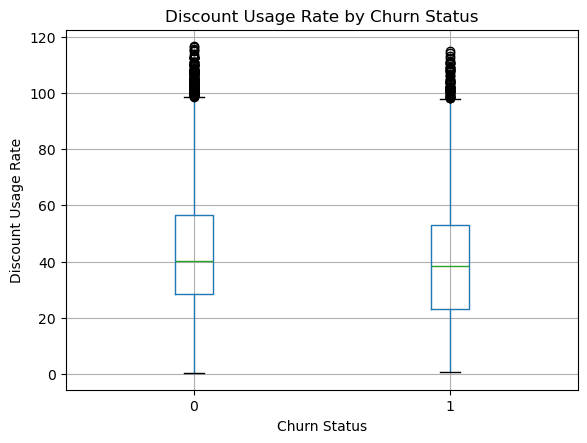

In [100]:
plt.figure(figsize=(6,4))

df.boxplot(column='Discount_Usage_Rate', by='Churned')

plt.title('Discount Usage Rate by Churn Status')
plt.suptitle('')
plt.xlabel('Churn Status')
plt.ylabel('Discount Usage Rate')

plt.show()

#### **Insight**
The statistics show that active customers use discounts slightly more frequently than churned customers. The average discount usage rate for active customers is 42.89%, while churned customers have an average of 39.38%.

#### **2.6 Pages per session vs Customer Churn**

#### **Objective**
The objective of this analysis is to compare the average number of pages viewed per session between active customers and churned customers.

In [101]:
df.groupby('Churned')['Pages_Per_Session'].mean()

Churned
0    9.223921
1    7.418482
Name: Pages_Per_Session, dtype: float64

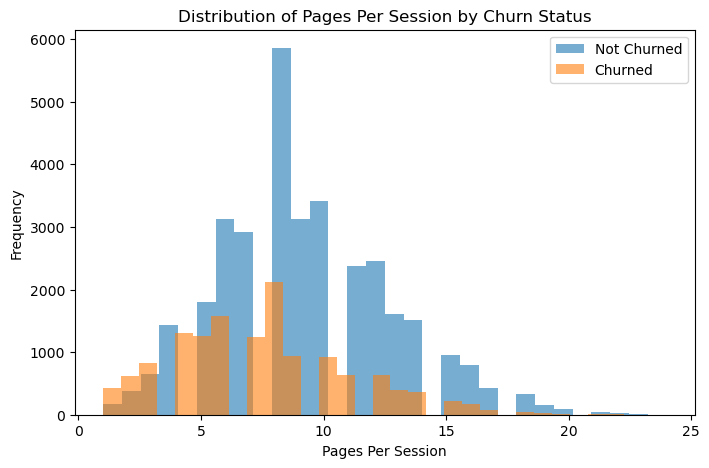

In [102]:
plt.figure(figsize=(8,5))

plt.hist(df[df['Churned']==0]['Pages_Per_Session'], bins=30, alpha=0.6, label='Not Churned')
plt.hist(df[df['Churned']==1]['Pages_Per_Session'], bins=30, alpha=0.6, label='Churned')
plt.title('Distribution of Pages Per Session by Churn Status')
plt.xlabel('Pages Per Session')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### **Insight**
- The results show that active customers view more pages per session (about 9 pages) compared to churned customers who view around 7 pages per session.

#### **2.7 Cart Abandonment rate vs Customer Churn**

#### **Objective**
To understand whether cart abandonment behavior is related to customer churn.

In [103]:
df.groupby('Churned')['Cart_Abandonment_Rate'].mean()

Churned
0    54.177519
1    64.104325
Name: Cart_Abandonment_Rate, dtype: float64

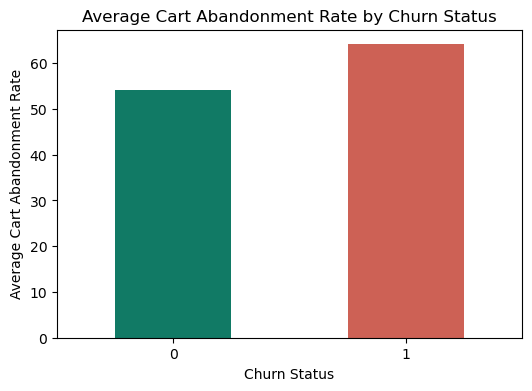

In [104]:
df.groupby('Churned')['Cart_Abandonment_Rate'].mean().plot(
    kind='bar',
    figsize=(6,4),
    color=['#117A65','#CD6155']
)
plt.title('Average Cart Abandonment Rate by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average Cart Abandonment Rate')
plt.xticks(rotation=0)
plt.show()

#### **Insight**
Customers with higher cart abandonment rates are more likely to churn, suggesting hesitation during the purchase process or dissatisfaction with pricing, delivery, or checkout experience.

### **3. Multivariate Analysis**

#### **3.1 Engagement vs Purchases vs Churn**

#### **Objective :**
Analyze how customer engagement affects purchasing behavior and churn.

In [105]:
cols = ['Login_Frequency','Session_Duration_Avg','Pages_Per_Session',
        'Total_Purchases','Average_Order_Value','Lifetime_Value',
        'Cart_Abandonment_Rate','Days_Since_Last_Purchase']
df[cols].corr()

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Total_Purchases,Average_Order_Value,Lifetime_Value,Cart_Abandonment_Rate,Days_Since_Last_Purchase
Login_Frequency,1.000000,0.685290,0.652198,0.589270,0.008488,0.498972,-0.625196,0.003923
Session_Duration_Avg,0.685290,1.000000,0.711260,0.641875,0.001783,0.541886,-0.677171,-0.000823
Pages_Per_Session,0.652198,0.711260,1.000000,0.605429,0.007488,0.513285,-0.645997,0.001791
Total_Purchases,0.589270,0.641875,0.605429,1.000000,0.003411,0.623305,-0.577421,0.009314
Average_Order_Value,0.008488,0.001783,0.007488,0.003411,1.000000,0.148137,-0.004011,-0.000072
Lifetime_Value,0.498972,0.541886,0.513285,0.623305,0.148137,1.000000,-0.495658,0.006592
Cart_Abandonment_Rate,-0.625196,-0.677171,-0.645997,-0.577421,-0.004011,-0.495658,1.000000,-0.003349
Days_Since_Last_Purchase,0.003923,-0.000823,0.001791,0.009314,-0.000072,0.006592,-0.003349,1.000000


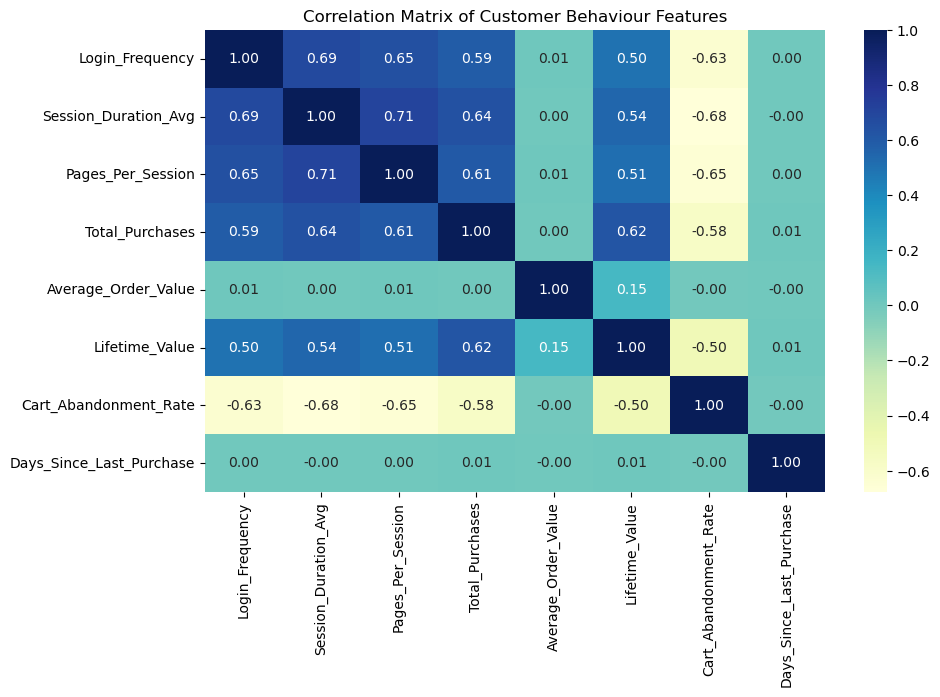

In [106]:
plt.figure(figsize=(10,6))

sns.heatmap(df[cols].corr(),
            annot=True,
            cmap='YlGnBu',
            fmt='.2f')

plt.title('Correlation Matrix of Customer Behaviour Features')

plt.show()

#### **Insight :**
- Login_Frequency, Pages_Per_Session, and Session_Duration may show positive correlations, indicating that more active users tend to spend more time and explore more pages.
- Total_Purchases and Lifetime_Value usually show a strong positive relationship since frequent purchases contribute to higher customer lifetime value.
- Days_Since_Last_Purchase may show a negative relationship with engagement metrics, suggesting that customers who have not purchased recently tend to be less active.

#### **3.2 Browsing Behavior vs Purchase Value**

#### **Objective :**
Understand how browsing activity influences customer spending.

In [107]:
df.groupby(['Gender','Churned'])['Total_Purchases'].mean()

Gender  Churned
Female  0          13.808318
        1          11.376758
Male    0          13.832046
        1          11.353174
Other   0          14.358333
        1          11.385714
Name: Total_Purchases, dtype: float64

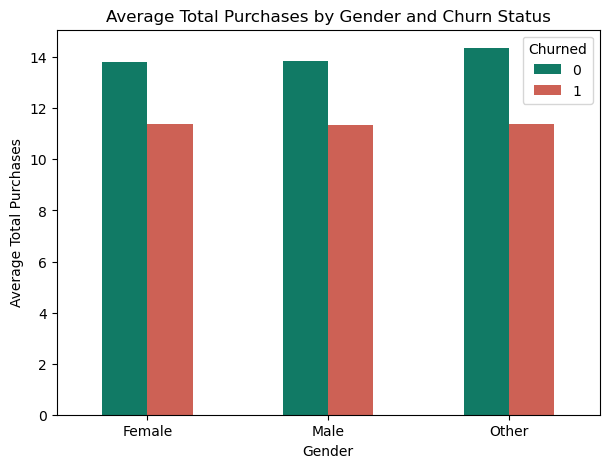

In [108]:
df.groupby(['Gender','Churned'])['Total_Purchases'].mean().unstack().plot(
    kind='bar',
    figsize=(7,5),
    color=['#117A65','#CD6155']
)
plt.title('Average Total Purchases by Gender and Churn Status')
plt.xlabel('Gender')
plt.ylabel('Average Total Purchases')

plt.xticks(rotation=0)

plt.legend(title='Churned')

plt.show()

#### **Insight**

- This suggests that gender does not appear to strongly influence purchase frequency or churn behavior in this dataset. 
- Customers from all gender groups demonstrate similar purchasing patterns, indicating that churn may be driven more by engagement factors such as login frequency, session activity, or browsing behavior rather than demographic characteristics like gender.

#### **3.3 Customer Value vs Purchase Behavior**

#### **Objective** : Analyze how purchase behavior contributes to overall customer value.

In [109]:
df[['Total_Purchases','Average_Order_Value','Lifetime_Value']].corr()

,Total_Purchases,Average_Order_Value,Lifetime_Value
Total_Purchases,1.000000,0.003411,0.623305
Average_Order_Value,0.003411,1.000000,0.148137
Lifetime_Value,0.623305,0.148137,1.000000


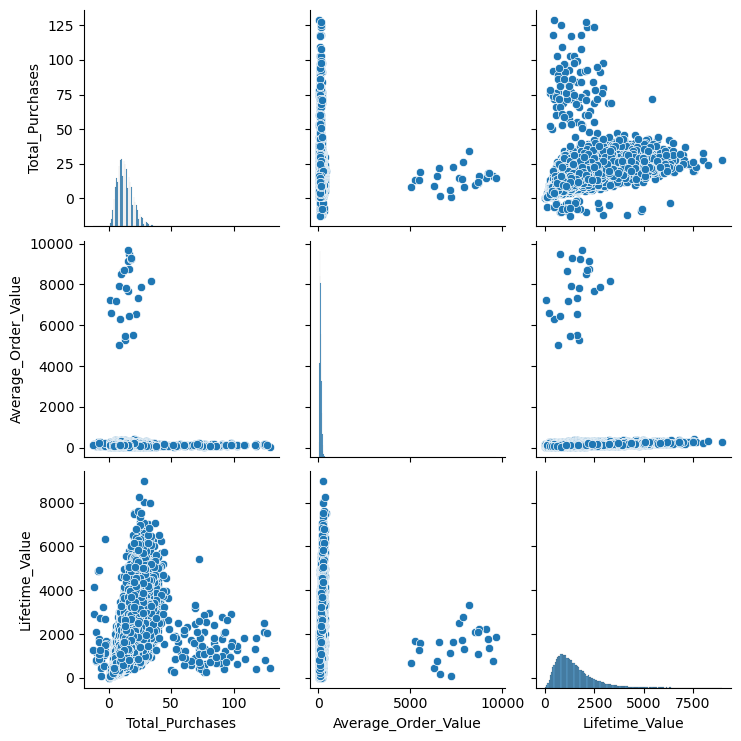

In [110]:
sns.pairplot(df[['Total_Purchases',
                 'Average_Order_Value',
                 'Lifetime_Value']])
plt.show()


#### **Insight :** 
- Total_Purchases & Lifetime_Value (0.62)
There is a moderate positive relationship, indicating that customers who purchase more frequently tend to generate higher lifetime value.

- Average_Order_Value & Lifetime_Value (0.15)
This shows a weak positive relationship, suggesting that higher spending per order contributes slightly to lifetime value, but its impact is limited.

- Total_Purchases & Average_Order_Value (0.00)
There is no significant relationship, meaning customers who purchase more often do not necessarily spend more per order.

#### **3.4 Customer Support Interaction vs Churn**

#### **Objective :**
Examine how customer service interactions affect churn behavior.

In [111]:
df.groupby('Churned')[['Customer_Service_Calls','Returns_Rate']].mean()

,Customer_Service_Calls,Returns_Rate
Churned,,
0,5.185507,6.371761
1,6.886026,7.025783


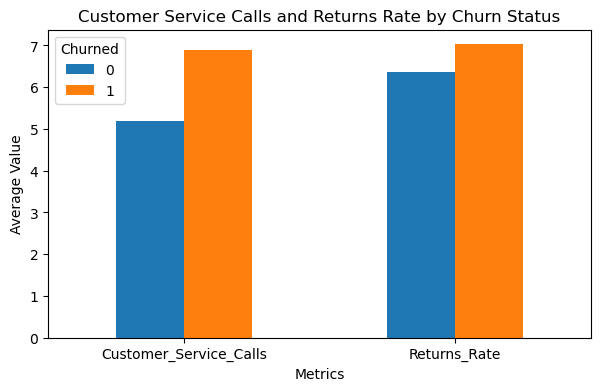

In [112]:
metrics = df.groupby('Churned')[['Customer_Service_Calls','Returns_Rate']].mean()
metrics.T.plot(kind='bar',
               figsize=(7,4))
plt.title('Customer Service Calls and Returns Rate by Churn Status')
plt.xlabel('Metrics')
plt.ylabel('Average Value')

plt.xticks(rotation=0)
plt.legend(title='Churned')

plt.show()

#### **Insight :**
Customers with frequent service calls and higher return rates tend to churn more, indicating potential dissatisfaction.

#### **3.5 Cart Abandonment vs Engagement vs Purchases**

#### **Objective**
Understand how cart abandonment combined with engagement affects purchasing behavior.

In [113]:
df[['Cart_Abandonment_Rate','Pages_Per_Session','Login_Frequency','Total_Purchases']].corr()

,Cart_Abandonment_Rate,Pages_Per_Session,Login_Frequency,Total_Purchases
Cart_Abandonment_Rate,1.000000,-0.645997,-0.625196,-0.577421
Pages_Per_Session,-0.645997,1.000000,0.652198,0.605429
Login_Frequency,-0.625196,0.652198,1.000000,0.589270
Total_Purchases,-0.577421,0.605429,0.589270,1.000000


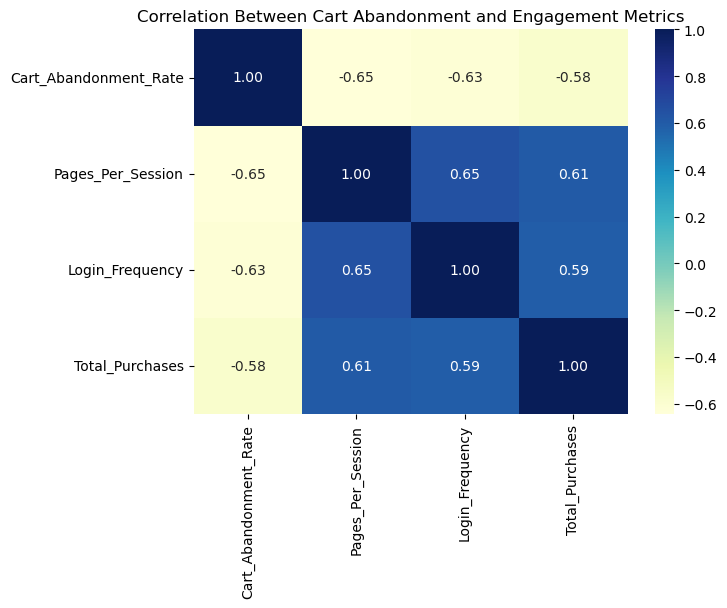

In [114]:
corr_matrix = df[['Cart_Abandonment_Rate',
                  'Pages_Per_Session',
                  'Login_Frequency',
                  'Total_Purchases']].corr()

plt.figure(figsize=(7,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='YlGnBu',
            fmt='.2f')

plt.title('Correlation Between Cart Abandonment and Engagement Metrics')

plt.show()

#### **Insight**
- Cart abandonment rate has a strong negative correlation with:

Pages per session (-0.646)

Login frequency (-0.625)

Total purchases (-0.577)

- This indicates that more engaged customers are less likely to abandon their carts

- Pages per session and login frequency show a strong positive relationship (0.652)
→ Customers who log in more tend to browse more

- Pages per session and total purchases have a strong positive correlation (0.605)
→ More browsing leads to higher purchasing

- Login frequency and total purchases are also positively correlated (0.589)
→ Frequent users tend to purchase more

#### **3.6 Customer Support Interaction vs Engagement vs Churn**

#### **Objective**
Examine how customer support interactions and engagement levels together influence churn behavior.

In [115]:
df.groupby('Churned')[['Customer_Service_Calls','Email_Open_Rate','Login_Frequency']].mean()

,Customer_Service_Calls,Email_Open_Rate,Login_Frequency
Churned,,,
0,5.185507,22.809942,12.644095
1,6.886026,16.224568,9.143570


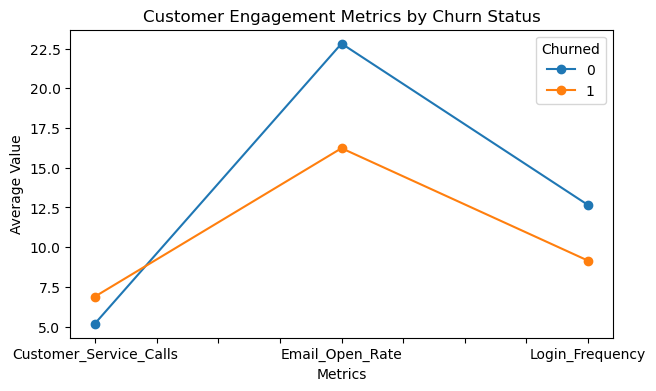

In [116]:
df.groupby('Churned')[['Customer_Service_Calls',
                       'Email_Open_Rate',
                       'Login_Frequency']].mean().T.plot(
    marker='o',
    figsize=(7,4)
)
plt.title('Customer Engagement Metrics by Churn Status')
plt.xlabel('Metrics')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Churned')
plt.show()

#### **Insight**
Customers with higher service calls and lower engagement levels are more likely to churn, suggesting that customer dissatisfaction combined with low platform interaction increases churn risk.

## **Visualizations using Plotly**

#### **1. Churn Distribution**

#### **Objective**
To understand the proportion of churned vs active customers.

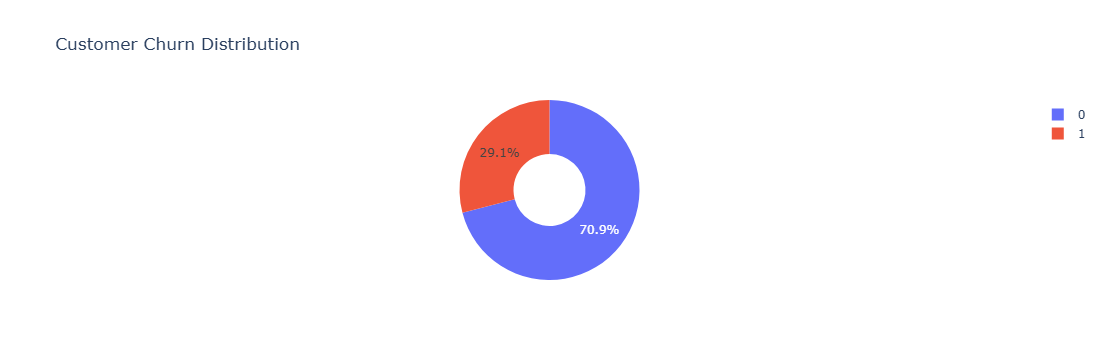

In [117]:
fig = px.pie(df,
             names='Churned',
             title='Customer Churn Distribution',
             hole=0.4)

fig.show()

#### **Insight**

- The visualization shows the proportion of active and churned customers in the dataset.

- A higher percentage of active customers indicates stable platform engagement, while the churned portion represents users who stopped interacting with the platform.

- Understanding this distribution helps businesses estimate customer retention levels and identify the need for churn reduction strategies.

#### **2. RFM Segment Distribution**

#### **Objective** 
To visualize the number of customers in each RFM segment

In [118]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment','Count']

fig = px.bar(segment_counts,
             x='Segment',
             y='Count',
             title='Customer Distribution by RFM Segment',
             color='Segment')

fig.show()

### **Insight**
- The RFM segmentation highlights different groups of customers based on their purchasing behavior.

- Champions and Loyal Customers represent the most valuable users who frequently purchase and contribute significantly to revenue.

- Frequent Buyers show consistent purchasing behavior and represent potential high-value customers.

- At Risk customers require attention since their reduced activity indicates a higher probability of churn.

#### **3. Engagement Funnel**

#### **Objective**
Compare engagement metrics between churned and active customers.

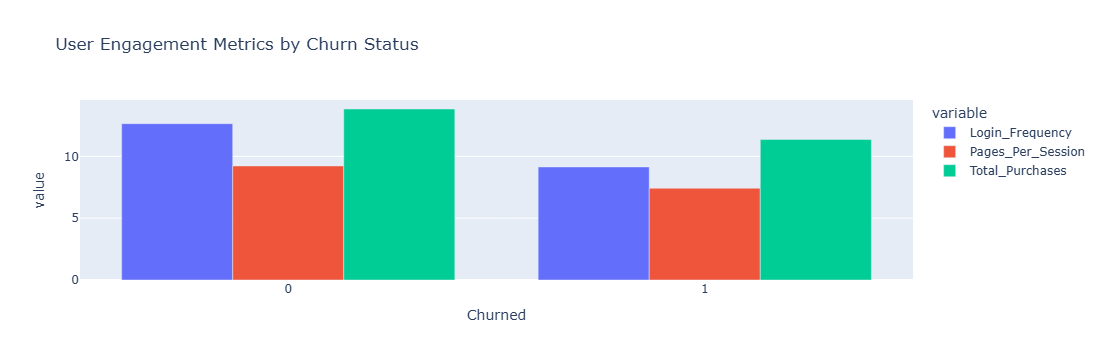

In [119]:
funnel = df.groupby('Churned')[[
    'Login_Frequency',
    'Pages_Per_Session',
    'Total_Purchases'
]].mean().reset_index()

fig = px.bar(funnel,
             x='Churned',
             y=['Login_Frequency','Pages_Per_Session','Total_Purchases'],
             barmode='group',
             title='User Engagement Metrics by Churn Status')

fig.show()

#### **Insight**
- Active customers generally show higher login frequency, more pages per session, and greater purchase activity.

- Churned customers display lower engagement across these metrics, indicating that reduced platform interaction -often precedes churn.

- This suggests that monitoring engagement metrics can help identify customers likely to churn.--

#### **4. Correlation Heatmap**

#### **Objective**

To analyze relationships between key numeric variables.

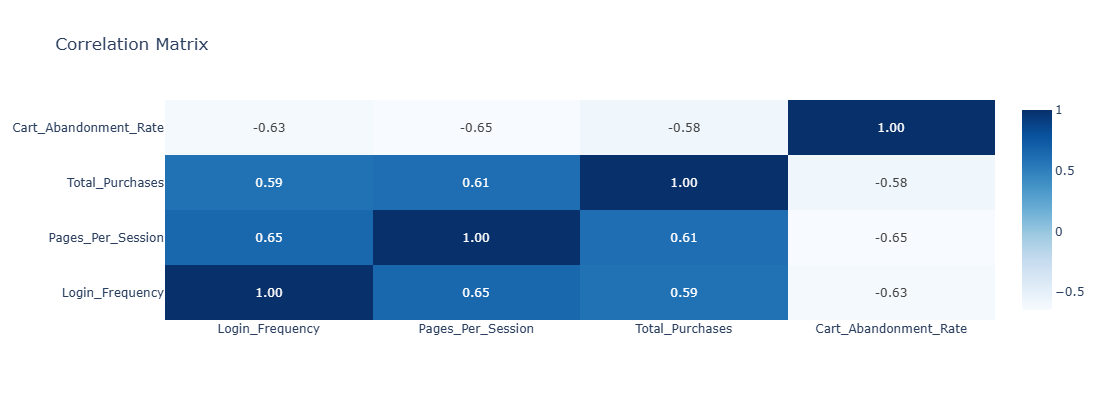

In [120]:
import plotly.graph_objects as go

# Correlation matrix
corr = df[['Login_Frequency',
           'Pages_Per_Session',
           'Total_Purchases',
           'Cart_Abandonment_Rate']].corr()

# Plot
fig = go.Figure(
    data=go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale='Blues',
        text=corr.values,
        texttemplate="%{text:.2f}"
    )
)

fig.update_layout(
    title="Correlation Matrix",
    width=600,
    height=400
)

fig.show()

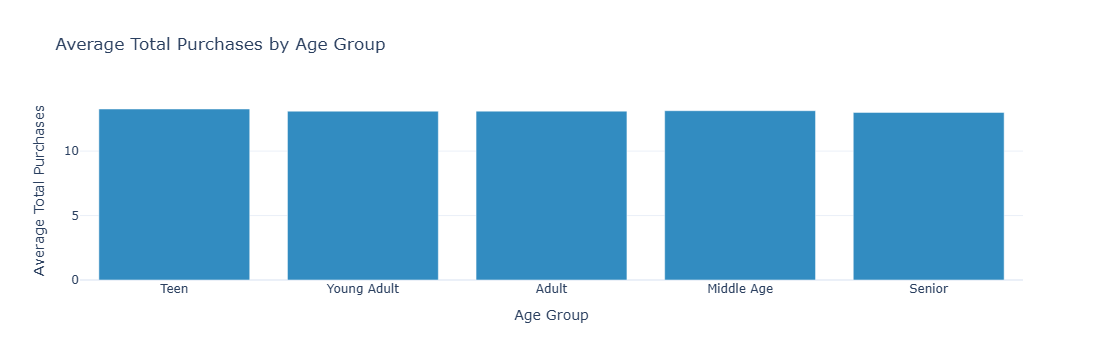

In [121]:
# Aggregate data
age_purchase = df.groupby('Age_Group')['Total_Purchases'].mean().reset_index()

# Plot
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=age_purchase['Age_Group'],
        y=age_purchase['Total_Purchases'],
        marker=dict(color='#328CC1')
    )
)

fig.update_layout(
    title="Average Total Purchases by Age Group",
    xaxis_title="Age Group",
    yaxis_title="Average Total Purchases",
    template="plotly_white"
)

fig.show()

## Dashboard Using Plotly

In [122]:
# ---- Required Data Preparation ----
churn_counts = df['Churned'].value_counts()

segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

engagement = df.groupby('Churned')[[
    'Login_Frequency',
    'Pages_Per_Session',
    'Total_Purchases'
]].mean().reset_index()

corr = df[[
    'Login_Frequency',
    'Pages_Per_Session',
    'Total_Purchases',
    'Cart_Abandonment_Rate'
]].corr()

# ---- Color Palette ----
palette = ['#0B3C5D', '#328CC1', '#66A5AD', '#D9E4EC', '#F2F6F9']

# ---- Dashboard Layout ----
fig = make_subplots(
    rows=3,
    cols=2,
    subplot_titles=(
        "Customer Churn Distribution",
        "RFM Segment Distribution",
        "User Engagement by Churn Status",
        "Distribution of Total Purchases",
        "",
        "Correlation Heatmap"
    ),
    specs=[
        [{'type': 'domain'}, {'type': 'xy'}],
        [{'type': 'xy'}, {'type': 'xy'}],
        [{'type': 'xy'}, {'type': 'heatmap'}]
    ],
    horizontal_spacing=0.12,
    vertical_spacing=0.15
)

# ---- 1. Churn Pie ----
fig.add_trace(
    go.Pie(
        labels=churn_counts.index,
        values=churn_counts.values,
        hole=0.4,
        marker=dict(colors=palette)
    ),
    row=1, col=1
)

# ---- 2. RFM Segment Bar ----
fig.add_trace(
    go.Bar(
        x=segment_counts['Segment'],
        y=segment_counts['Count'],
        marker=dict(color=palette[1])
    ),
    row=1, col=2
)

# ---- 3. Engagement Metrics ----
metrics = ['Login_Frequency', 'Pages_Per_Session', 'Total_Purchases']

for i, col in enumerate(metrics):
    fig.add_trace(
        go.Bar(
            x=engagement['Churned'],
            y=engagement[col],
            name=col,
            marker=dict(color=palette[i])
        ),
        row=2, col=1
    )

# ---- 4. Histogram ----
fig.add_trace(
    go.Histogram(
        x=df['Total_Purchases'],
        nbinsx=30,
        marker=dict(color=palette[2])
    ),
    row=2, col=2
)

# ---- 5. Correlation Heatmap ----
fig.add_trace(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        colorscale='Blues'
    ),
    row=3, col=2
)

# ---- Layout ----
fig.update_layout(
    height=1200,
    width=1100,
    title="E-Commerce Customer Behavior Dashboard",
    template="plotly_white",
    legend=dict(orientation="h", y=-0.05),
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.show()

<h2 style='color:#117A65;'>6.Overall Insight</h2>
The exploratory data analysis reveals that customer engagement and purchasing behavior are the primary drivers of customer value and retention in the e-commerce platform. Metrics such as login frequency, pages per session, and total purchases show strong relationships with customer activity, indicating that highly engaged users tend to generate higher revenue and lifetime value.

- The analysis also shows that customers with lower engagement levels are more likely to churn, highlighting the importance of monitoring behavioral metrics to identify at-risk users early. In contrast, customers who interact frequently with the platform demonstrate higher purchasing frequency and spending behavior.

- RFM segmentation further emphasizes these behavioral patterns by identifying high-value segments such as Champions and Loyal Customers, who contribute significantly to overall revenue. At the same time, At Risk segments show declining engagement, suggesting the need for targeted retention strategies.

- Demographic factors such as age and gender show minimal influence on purchasing patterns, indicating that behavioral data provides stronger insights into customer activity than demographic attributes.

- Overall, the findings suggest that businesses should focus on enhancing customer engagement, nurturing high-value segments, and implementing proactive retention strategies to improve customer lifetime value and reduce churn.

<h2 style='color:#117A65;'>7. Conclusion</h2>

- The project conducted exploratory data analysis to examine customer behavior, engagement levels, and purchasing patterns within an e-commerce platform through churn analysis, demographic evaluation, correlation analysis, and RFM segmentation. The findings show that customer engagement metrics such as login frequency, browsing activity, and purchase frequency plays a significant role in customer retention and lifetime value.

- The analysis also indicates that demographic factors like age and gender have limited influence on purchasing behavior, emphasizing that behavioral data provides more meaningful insights into customer activity. RFM segmentation helps identify high value customers such as Champions and Loyal Customers, while also highlighting At Risk customers who may require targeted retention strategies.

- Overall, the study suggests that improving customer engagement and prioritizing high-value segments can enhance customer retention, increase lifetime value, and enable more effective data-driven marketing strategies.

<h2 style='color:#117A65;'>8. Recommendations</h2>

- #### Focus on Customer Engagement :
Enhancing user engagement through personalized recommendations, improved user experience, and targeted notifications can increase purchasing activity and customer retention.

- #### Strengthen Retention Strategies :
Customers identified as At Risk should be targeted with re-engagement strategies such as personalized offers, discounts, and reminder campaigns to reduce potential churn.


- #### Reward High-Value Customers :
Businesses should prioritize Champions and Loyal Customers by offering loyalty rewards, exclusive benefits, and personalized experiences to maintain long-term relationships.

- #### Convert Frequent Buyers into Champions :
Frequent buyers represent a high-potential segment. Targeted promotions, upselling, and cross-selling strategies can help increase their spending and engagement.

- #### Leverage Behavioral Data for Decision Making :
Since demographic factors show limited influence on purchasing behavior, businesses should rely more on behavioral analytics and engagement metrics for customer segmentation and marketing strategies.
